# Chapter 6 — The Simple Spatial Prisoner's Dilemma
**Modeling Social Behavior** | Smaldino

---

## What This Model Does

This notebook implements the **simple spatial cooperation model** from Section 6.3.1.

The core idea: place agents on a grid, have each one interact only with its four immediate neighbors, and let successful strategies spread locally through imitation. No memory, no reciprocity — just pure strategies (always cooperate or always defect) competing in a structured environment.

**The big question:** Can spatial structure alone rescue cooperation, even when defection is the individually rational strategy?

---

## Model Summary

| Component | Description |
|---|---|
| **Population** | N agents on an L × L square grid with toroidal (wrap-around) boundaries |
| **Strategies** | Two pure strategies: Cooperator (C) or Defector (D) |
| **Interactions** | Each agent plays the PD with its 4 immediate neighbors (von Neumann neighborhood) |
| **Payoff parameters** | `b` = benefit given to partner; `c` = cost paid by cooperator |
| **Evolution** | Each agent copies the strategy of its highest-payoff neighbor (if better than itself) |
| **Time step** | Two stages: (1) play game → accumulate payoffs, (2) evolve → copy best neighbor |

---

## Variable Types

Throughout this notebook, variables fall into three categories:

- **Global variables** — shared by all agents and the environment (e.g., `b`, `c`, grid size)
- **Agent variables** — each agent has its own copy (e.g., `strategy`, `payoff`)
- **Local variables** — created temporarily inside a function, then discarded (e.g., loop counters, neighbor lists)


## Step 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import random

# Set a random seed for reproducibility
# Remove or change this to get different runs
random.seed(42)
np.random.seed(42)


## Step 2 — Global Parameters

These are the **global variables** of the model — shared values that every agent can access.

- `L` — the side length of the grid. Population size will be L × L.
- `b` — the benefit a cooperator confers on its partner per interaction.
- `c` — the cost a cooperator pays per interaction (always c < b).
- `init_coop_freq` — the starting proportion of cooperators, assigned randomly.

> **Smaldino's convention:** Fix `b = 1` and vary only `c`.  
> This way, `c` directly expresses the cost as a fraction of the benefit,  
> and the critical threshold `c = b/4 = 0.25` is easy to reason about.


In [2]:
# ── GLOBAL VARIABLES ──────────────────────────────────────────────────────

L = 31                  # Grid side length → population size = 31×31 = 961 agents
                        # (matches Smaldino's 31×31 toroidal lattice)

b = 1.0                 # Benefit: what a cooperator gives to its partner
c = 0.20                # Cost: what a cooperator pays per interaction
                        # Try values around 0.25 to observe the phase transition

init_coop_freq = 0.5    # Starting proportion of cooperators (50%)

# Derived global
N = L * L               # Total number of agents
print(f"Grid: {L}×{L} = {N} agents")
print(f"Payoff parameters: b={b}, c={c}")
print(f"Critical threshold b/4 = {b/4:.3f}  →  cost is {'BELOW' if c < b/4 else 'ABOVE'} threshold")


Grid: 31×31 = 961 agents
Payoff parameters: b=1.0, c=0.2
Critical threshold b/4 = 0.250  →  cost is BELOW threshold


## Step 3 — Agent Representation

Each agent has two **agent variables** — values that belong to the individual agent and differ from agent to agent:

- `strategy` — integer: `1` = cooperator, `0` = defector
- `payoff` — float: the total payoff accumulated this time step from all neighbor interactions

We represent the whole population as two 2D NumPy arrays of shape `(L, L)` — one for strategies and one for payoffs.  
Each cell `[row, col]` in the array is one agent on the grid.

> **Why arrays instead of a list of objects?**  
> Arrays allow us to perform operations on all agents simultaneously using NumPy,  
> which is much faster than looping over individual agent objects in Python.


In [3]:
# ── AGENT VARIABLES (stored as 2D arrays) ────────────────────────────────

def initialize_grid(L, init_coop_freq, seed=None):
    """
    Create the starting population.
    
    Each cell gets a strategy assigned randomly:
    - With probability init_coop_freq  → cooperator (strategy = 1)
    - Otherwise                        → defector   (strategy = 0)
    
    Parameters
    ----------
    L : int
        Side length of the square grid.
    init_coop_freq : float
        Probability [0, 1] that any given agent starts as a cooperator.
    seed : int or None
        Optional random seed for reproducibility.
    
    Returns
    -------
    strategy : np.ndarray of shape (L, L), dtype int
        Agent variable — 1 = cooperator, 0 = defector.
    payoff : np.ndarray of shape (L, L), dtype float
        Agent variable — initialized to 0 for every agent.
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Draw a random float in [0, 1) for each cell;
    # cells below the threshold become cooperators
    strategy = (np.random.random((L, L)) < init_coop_freq).astype(int)
    
    # All payoffs start at zero
    payoff = np.zeros((L, L), dtype=float)
    
    return strategy, payoff


# Initialize the model
strategy, payoff = initialize_grid(L, init_coop_freq, seed=42)

# Quick sanity check
actual_freq = strategy.mean()
print(f"Initialized {N} agents.")
print(f"Cooperators: {strategy.sum()} ({actual_freq:.1%})")
print(f"Defectors:   {N - strategy.sum()} ({1 - actual_freq:.1%})")


Initialized 961 agents.
Cooperators: 481 (50.1%)
Defectors:   480 (49.9%)


## Step 4 — The Neighborhood

Each agent interacts with its **4 immediate neighbors** (up, down, left, right) — the von Neumann neighborhood. Diagonal neighbors are not included.

The grid has **toroidal boundaries**: the top edge wraps to the bottom, and the left edge wraps to the right.  
This means every agent has exactly 4 neighbors, with no edge or corner effects.

We implement this using NumPy's `np.roll()`, which shifts the entire array by one position in a given direction. Because arrays have toroidal wrapping by default with `roll`, this is a clean and efficient way to access all neighbors at once.


In [4]:
# ── NEIGHBORHOOD HELPER ──────────────────────────────────────────────────

def get_neighbors(grid):
    """
    Return the four von Neumann neighbors for every cell simultaneously.
    
    Uses np.roll() to shift the array in each of the 4 directions.
    The toroidal (wrap-around) boundary is handled automatically by roll.
    
    Parameters
    ----------
    grid : np.ndarray of shape (L, L)
        Any per-agent array (strategy, payoff, etc.).
    
    Returns
    -------
    neighbors : list of 4 np.ndarrays, each of shape (L, L)
        [north, south, east, west] — each array contains the value of
        that neighbor for every agent in the grid.
    
    Local variables
    ---------------
    Each shifted array is a local variable used only inside this function.
    """
    north = np.roll(grid, -1, axis=0)   # shift rows up   → each cell sees its southern neighbor
    south = np.roll(grid,  1, axis=0)   # shift rows down → each cell sees its northern neighbor
    east  = np.roll(grid, -1, axis=1)   # shift cols left → each cell sees its eastern neighbor
    west  = np.roll(grid,  1, axis=1)   # shift cols right→ each cell sees its western neighbor
    
    return [north, south, east, west]


# Quick visual check: look at the top-left corner of the strategy grid
print("Strategy grid (top-left 5×5 corner):")
print(strategy[:5, :5])
print()
print("North neighbor of that same corner (row above, wraps from bottom):")
print(get_neighbors(strategy)[0][:5, :5])


Strategy grid (top-left 5×5 corner):
[[1 0 0 0 1]
 [1 1 0 0 0]
 [0 1 1 0 1]
 [0 0 1 0 1]
 [1 1 0 0 1]]

North neighbor of that same corner (row above, wraps from bottom):
[[1 1 0 0 0]
 [0 1 1 0 1]
 [0 0 1 0 1]
 [1 1 0 0 1]
 [1 0 0 1 0]]


## Step 5 — Stage 1: Play the Game

Every agent plays the Prisoner's Dilemma with each of its 4 neighbors and accumulates a total payoff.

**Payoff rules (per interaction):**

| You \ Partner | Cooperates | Defects |
|---|---|---|
| **Cooperate** | `b - c` | `-c` |
| **Defect** | `b` | `0` |

Summing across all 4 neighbors:

- **Cooperator payoff:** `n_C × (b - c) - n_D × c`  
  where `n_C` = number of cooperating neighbors, `n_D` = number of defecting neighbors

- **Defector payoff:** `n_C × b`  
  Defectors only earn from cooperating neighbors; defector-vs-defector gives `0`.

We compute this for every agent at once using array operations.


In [5]:
# ── STAGE 1: PLAY GAME ───────────────────────────────────────────────────

def play_game(strategy, b, c):
    """
    Each agent plays the PD with each of its 4 neighbors.
    Payoffs are accumulated across all 4 interactions.
    
    Parameters
    ----------
    strategy : np.ndarray of shape (L, L)
        Agent variable — current strategy of every agent (1=C, 0=D).
    b : float
        Global variable — benefit conferred on a partner by cooperating.
    c : float
        Global variable — cost paid by cooperator per interaction.
    
    Returns
    -------
    payoff : np.ndarray of shape (L, L)
        Agent variable — updated total payoff for each agent this time step.
    
    Local variables
    ---------------
    neighbors     : list of 4 shifted strategy arrays (one per direction)
    n_C           : array counting cooperating neighbors for each agent
    n_D           : array counting defecting neighbors for each agent
    coop_payoff   : payoff formula applied only to cooperating agents
    defect_payoff : payoff formula applied only to defecting agents
    """
    # Get all 4 neighbors' strategies as shifted copies of the strategy array
    neighbors = get_neighbors(strategy)
    
    # Count how many neighbors are cooperators (strategy == 1)
    # Sum the 4 neighbor arrays — each cooperating neighbor contributes 1
    n_C = sum(neighbors)          # local variable: shape (L, L), values 0–4
    
    # Count defecting neighbors = 4 minus cooperating neighbors
    n_D = 4 - n_C                 # local variable: shape (L, L), values 0–4
    
    # Initialize payoff array to zero for this time step
    payoff = np.zeros_like(strategy, dtype=float)
    
    # Cooperator payoff: n_C × (b - c) - n_D × c
    # Only applied to cells where strategy == 1
    coop_mask = (strategy == 1)   # local variable: boolean mask for cooperators
    payoff[coop_mask] = (n_C[coop_mask] * (b - c)
                         - n_D[coop_mask] * c)
    
    # Defector payoff: n_C × b
    # Only applied to cells where strategy == 0
    defect_mask = (strategy == 0) # local variable: boolean mask for defectors
    payoff[defect_mask] = n_C[defect_mask] * b
    
    return payoff


# Test it
payoff = play_game(strategy, b, c)
print("Payoff grid (top-left 5×5 corner):")
print(np.round(payoff[:5, :5], 3))
print(f"\nPayoff range: [{payoff.min():.3f}, {payoff.max():.3f}]")
print(f"Mean cooperator payoff: {payoff[strategy==1].mean():.3f}")
print(f"Mean defector payoff:   {payoff[strategy==0].mean():.3f}")


Payoff grid (top-left 5×5 corner):
[[1.2 2.  0.  1.  1.2]
 [2.2 1.2 2.  0.  3. ]
 [2.  1.2 1.2 2.  0.2]
 [2.  3.  0.2 2.  2.2]
 [1.2 0.2 2.  2.  0.2]]

Payoff range: [-0.800, 4.000]
Mean cooperator payoff: 1.225
Mean defector payoff:   1.979


## Step 6 — Stage 2: Evolve (Copy the Best Neighbor)

After all payoffs are calculated, each agent looks at the payoffs of its 4 neighbors.  
If any neighbor has a **higher payoff** than the agent itself, the agent **copies that neighbor's strategy**.

Specifically, each agent adopts the strategy of whichever neighbor has the **highest payoff** — but only if that highest payoff exceeds the agent's own.

This is **success-biased imitation** — the evolutionary mechanism of the model.  
Strategies that produce higher payoffs spread locally through copying.

> **Important:** All agents update simultaneously. We look at the payoffs from *this* time step  
> to decide updates, then apply all updates at once. No agent has an advantage from going first.


In [6]:
# ── STAGE 2: EVOLVE ──────────────────────────────────────────────────────

def evolve(strategy, payoff):
    """
    Each agent compares its payoff to all 4 neighbors' payoffs.
    If a neighbor has a higher payoff, the agent copies that neighbor's strategy.
    The agent copies the neighbor with the HIGHEST payoff among all 4.
    All updates happen simultaneously (based on this time step's payoffs).
    
    Parameters
    ----------
    strategy : np.ndarray of shape (L, L)
        Agent variable — current strategies.
    payoff : np.ndarray of shape (L, L)
        Agent variable — payoffs from the current time step.
    
    Returns
    -------
    new_strategy : np.ndarray of shape (L, L)
        Agent variable — updated strategies after imitation.
    
    Local variables
    ---------------
    neighbor_payoffs   : list of 4 payoff arrays (one per direction)
    neighbor_strategies: list of 4 strategy arrays (one per direction)
    best_neighbor_payoff  : element-wise maximum payoff among the 4 neighbors
    best_neighbor_idx     : which of the 4 directions had the highest payoff
    new_strategy          : copy of strategy array, updated where imitation occurs
    """
    # Get all neighbors' payoffs and strategies
    neighbor_payoffs    = get_neighbors(payoff)    # local: list of 4 arrays
    neighbor_strategies = get_neighbors(strategy)  # local: list of 4 arrays
    
    # Stack the 4 neighbor payoff arrays into shape (4, L, L)
    # so we can take the element-wise maximum across the 4 directions
    stacked_payoffs = np.stack(neighbor_payoffs, axis=0)     # local: shape (4, L, L)
    stacked_strategies = np.stack(neighbor_strategies, axis=0)  # local: shape (4, L, L)
    
    # Find the maximum payoff among the 4 neighbors for each agent
    best_neighbor_payoff = stacked_payoffs.max(axis=0)        # local: shape (L, L)
    
    # Find which neighbor (direction index 0–3) had the highest payoff
    best_neighbor_idx = stacked_payoffs.argmax(axis=0)        # local: shape (L, L)
    
    # Retrieve the strategy of the best neighbor using advanced indexing
    # np.arange creates row and column index arrays so we can index all cells at once
    rows = np.arange(strategy.shape[0])[:, None]  # local: column vector of row indices
    cols = np.arange(strategy.shape[1])[None, :]  # local: row vector of col indices
    best_neighbor_strategy = stacked_strategies[best_neighbor_idx, rows, cols]  # local
    
    # Only copy if the best neighbor's payoff is strictly higher than the agent's own
    imitate_mask = best_neighbor_payoff > payoff   # local: boolean array
    
    # Apply updates: start from current strategy and overwrite where imitation occurs
    new_strategy = strategy.copy()
    new_strategy[imitate_mask] = best_neighbor_strategy[imitate_mask]
    
    return new_strategy


# Test it: run one evolution step and check if cooperator frequency changed
new_strategy = evolve(strategy, payoff)
old_freq = strategy.mean()
new_freq = new_strategy.mean()
print(f"Cooperator frequency before evolution: {old_freq:.3f}")
print(f"Cooperator frequency after  evolution: {new_freq:.3f}")
print(f"Change: {new_freq - old_freq:+.3f}")


Cooperator frequency before evolution: 0.501
Cooperator frequency after  evolution: 0.223
Change: -0.278


## Step 7 — Visualization Helper

A function to display the grid at any point in time.  
Blue = cooperator, Red = defector — matching the convention in the book.


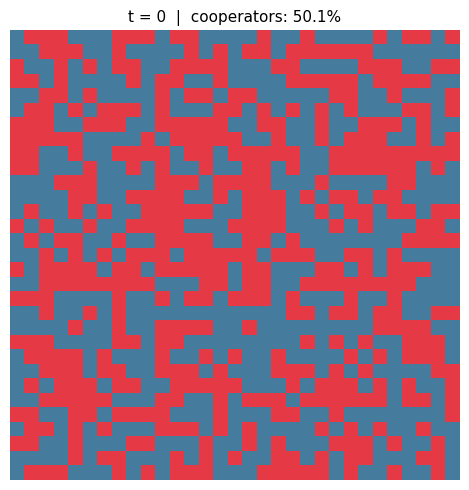

Blue = cooperator | Red = defector


In [7]:
# ── VISUALIZATION ────────────────────────────────────────────────────────

def plot_grid(strategy, t=None, ax=None, title=None):
    """
    Display the current state of the grid.
    Blue cells = cooperators (strategy=1), Red cells = defectors (strategy=0).
    
    Parameters
    ----------
    strategy : np.ndarray of shape (L, L)
        Agent variable — current strategies to visualize.
    t : int or None
        Current time step number, shown in the title.
    ax : matplotlib Axes or None
        If None, creates a new figure.
    title : str or None
        Custom title override.
    """
    # Create a colormap: 0 (defector) → red, 1 (cooperator) → blue
    cmap = mcolors.ListedColormap(['#e63946', '#457b9d'])  # red, blue
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    
    ax.imshow(strategy, cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
    ax.axis('off')
    
    freq = strategy.mean()
    if title:
        ax.set_title(title, fontsize=11)
    elif t is not None:
        ax.set_title(f"t = {t}  |  cooperators: {freq:.1%}", fontsize=11)
    else:
        ax.set_title(f"Cooperators: {freq:.1%}", fontsize=11)


# Show the initial state
fig, ax = plt.subplots(figsize=(5, 5))
plot_grid(strategy, t=0, ax=ax)
plt.tight_layout()
plt.show()
print("Blue = cooperator | Red = defector")


## Step 8 — The Full Simulation

We now assemble the two stages into a single time step, then run the model for many steps.

Each call to `step()` does exactly what Smaldino's `go` procedure does:
1. Play game → accumulate payoffs
2. Evolve → copy best neighbor


In [8]:
# ── SINGLE TIME STEP ─────────────────────────────────────────────────────

def step(strategy, b, c):
    """
    Advance the model by one time step.
    Combines the two stages: play game, then evolve.
    
    Parameters
    ----------
    strategy : np.ndarray of shape (L, L)
        Agent variable — strategies at the start of this step.
    b, c : float
        Global variables — payoff parameters.
    
    Returns
    -------
    new_strategy : np.ndarray of shape (L, L)
        Agent variable — strategies after this time step.
    coop_freq : float
        Proportion of cooperators after this step (for tracking over time).
    """
    payoff      = play_game(strategy, b, c)   # Stage 1
    new_strategy = evolve(strategy, payoff)   # Stage 2
    coop_freq   = new_strategy.mean()         # track cooperator frequency
    return new_strategy, coop_freq


# ── FULL SIMULATION ──────────────────────────────────────────────────────

def run_simulation(L, b, c, init_coop_freq, n_steps=50, seed=42,
                   snapshot_times=None):
    """
    Run the full model for n_steps time steps and record results.
    
    Parameters
    ----------
    L : int
        Global variable — grid side length.
    b, c : float
        Global variables — payoff parameters.
    init_coop_freq : float
        Global variable — initial cooperator frequency.
    n_steps : int
        How many time steps to run.
    seed : int
        Random seed for reproducibility.
    snapshot_times : list of int or None
        Time steps at which to save a copy of the full grid for visualization.
    
    Returns
    -------
    history : list of float
        Cooperator frequency at every time step (length n_steps + 1).
    snapshots : dict of {int: np.ndarray}
        Grid state saved at each requested snapshot time.
    """
    if snapshot_times is None:
        snapshot_times = []
    
    # Initialize
    strategy, _ = initialize_grid(L, init_coop_freq, seed=seed)
    
    # Record starting state
    history = [strategy.mean()]
    snapshots = {}
    if 0 in snapshot_times:
        snapshots[0] = strategy.copy()
    
    # Run for n_steps
    for t in range(1, n_steps + 1):
        strategy, coop_freq = step(strategy, b, c)
        history.append(coop_freq)
        
        if t in snapshot_times:
            snapshots[t] = strategy.copy()
        
        # Early stop if one strategy has completely taken over
        if coop_freq == 0.0 or coop_freq == 1.0:
            print(f"  Stopped early at t={t}: cooperator freq = {coop_freq:.3f}")
            # Pad history to full length so plots are consistent
            history += [coop_freq] * (n_steps - t)
            break
    
    return history, snapshots


# Run with default parameters (c=0.20, well below threshold of 0.25)
print(f"Running with b={b}, c={c}, init_coop_freq={init_coop_freq}")
print(f"Phase transition threshold: c = b/4 = {b/4}")

snapshot_times = [0, 1, 2, 3, 4, 5, 6, 7, 15]
history, snapshots = run_simulation(
    L, b, c, init_coop_freq,
    n_steps=50,
    seed=42,
    snapshot_times=snapshot_times
)

print(f"\nFinal cooperator frequency: {history[-1]:.3f}")


Running with b=1.0, c=0.2, init_coop_freq=0.5
Phase transition threshold: c = b/4 = 0.25

Final cooperator frequency: 0.791


## Step 9 — Spatial Snapshots (Recreating Figure 6.2)

Plot the grid at several time steps to observe how cooperative clusters form.  
This recreates Figure 6.2 from the book.


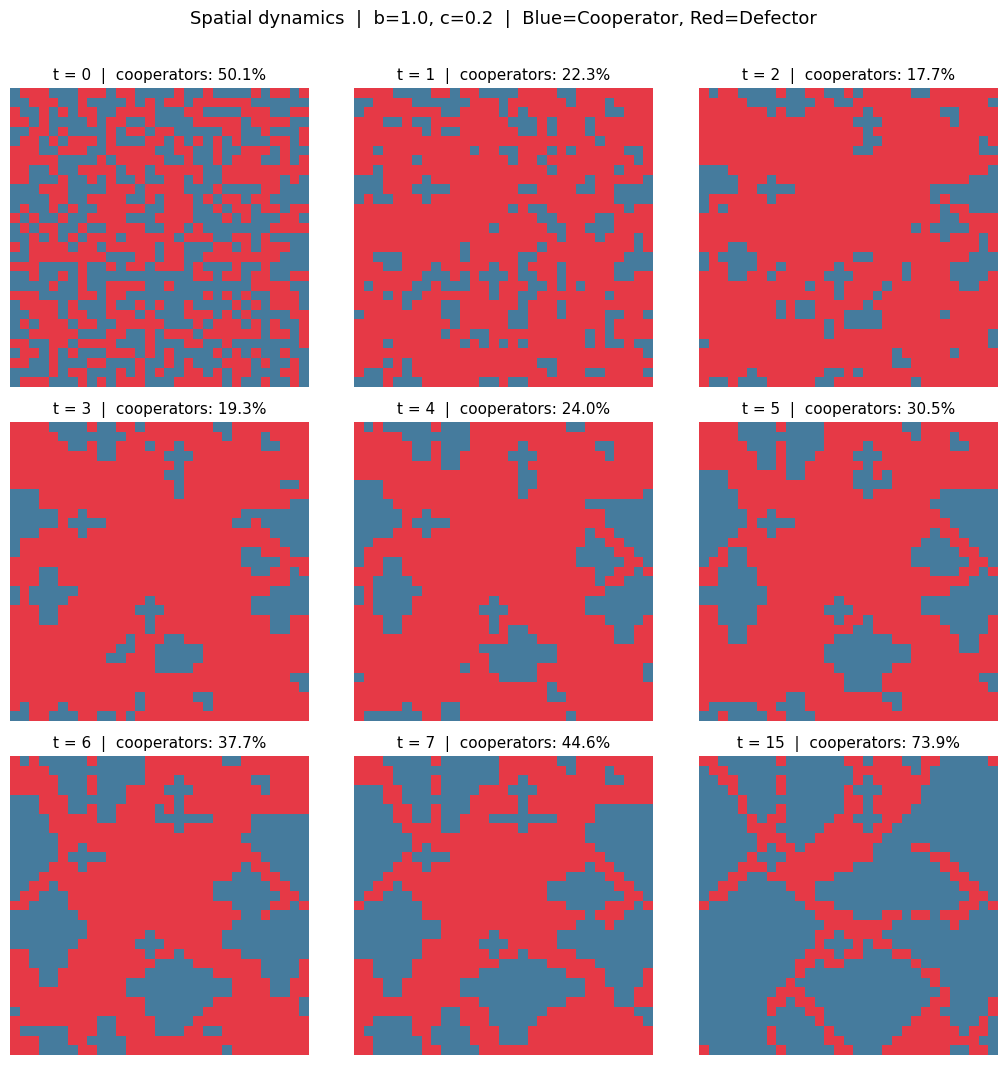

In [9]:
# ── SPATIAL SNAPSHOTS (Figure 6.2 equivalent) ────────────────────────────

available = sorted(snapshots.keys())
n_panels  = len(available)
cols      = 3
rows      = (n_panels + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
axes = axes.flatten()

for i, t in enumerate(available):
    plot_grid(snapshots[t], t=t, ax=axes[i])

# Hide any unused panels
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle(f"Spatial dynamics  |  b={b}, c={c}  |  Blue=Cooperator, Red=Defector",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Step 10 — Cooperator Frequency Over Time (Recreating Figure 6.1 Right Panel)

Plot how the proportion of cooperators changes across time steps.  
Compare this to Figure 6.1 (right panel) in the book.


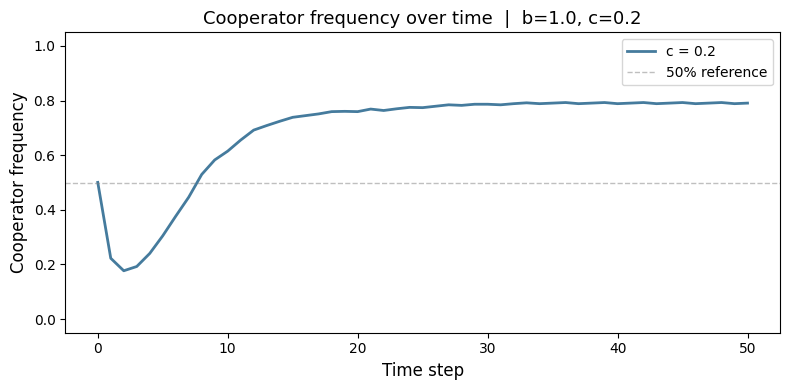

In [10]:
# ── COOPERATOR FREQUENCY OVER TIME ───────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(history, color='#457b9d', linewidth=2, label=f'c = {c}')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5,
           label='50% reference')

ax.set_xlabel("Time step", fontsize=12)
ax.set_ylabel("Cooperator frequency", fontsize=12)
ax.set_title(f"Cooperator frequency over time  |  b={b}, c={c}", fontsize=13)
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.tight_layout()
plt.show()


## Step 11 — The Phase Transition (Recreating Figure 6.3)

Now we vary `c` systematically and record the equilibrium cooperator frequency for each value.  
This recreates Figure 6.3 from the book — the sharp phase transition at `c = b/4`.

We run multiple simulations per value of `c` to capture variability (just like Smaldino's 10 runs).

> ⚠️ **This cell takes a minute or two to run** — it's running many simulations.


Running 50 cost values × 10 runs = 500 simulations...
  Stopped early at t=2: cooperator freq = 0.000
  Stopped early at t=3: cooperator freq = 0.000
  Stopped early at t=2: cooperator freq = 0.000
  Stopped early at t=3: cooperator freq = 0.000
  Stopped early at t=3: cooperator freq = 0.000
  Stopped early at t=3: cooperator freq = 0.000
  Stopped early at t=3: cooperator freq = 0.000
  Stopped early at t=2: cooperator freq = 0.000
  Stopped early at t=3: cooperator freq = 0.000
  Stopped early at t=3: cooperator freq = 0.000
  Stopped early at t=3: cooperator freq = 0.000
  Stopped early at t=3: cooperator freq = 0.000
  Stopped early at t=3: cooperator freq = 0.000
  Stopped early at t=2: cooperator freq = 0.000
  Stopped early at t=3: cooperator freq = 0.000
  Stopped early at t=3: cooperator freq = 0.000
  Stopped early at t=3: cooperator freq = 0.000
  Stopped early at t=3: cooperator freq = 0.000
  Stopped early at t=3: cooperator freq = 0.000
  Stopped early at t=3: cooperator

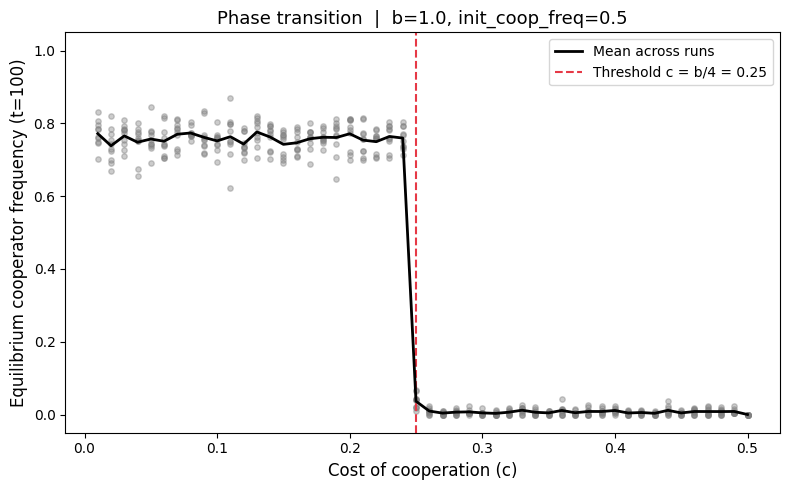

In [11]:
# ── PHASE TRANSITION SWEEP (Figure 6.3 equivalent) ───────────────────────

# Global parameters for this sweep
b_sweep      = 1.0                          # fix benefit at 1
c_values     = np.arange(0.01, 0.51, 0.01)  # vary cost from 0.01 to 0.50
n_runs       = 10                           # runs per cost value
n_steps_sweep = 100                         # steps per run

# Store equilibrium frequency for each run and each cost value
# Shape: (n_c_values, n_runs)
results = np.zeros((len(c_values), n_runs))

print(f"Running {len(c_values)} cost values × {n_runs} runs = "
      f"{len(c_values)*n_runs} simulations...")

for i, c_val in enumerate(c_values):
    for run in range(n_runs):
        hist, _ = run_simulation(
            L, b_sweep, c_val, init_coop_freq,
            n_steps=n_steps_sweep,
            seed=run * 100 + i   # different seed per run
        )
        results[i, run] = hist[-1]   # record final (equilibrium) frequency

print("Done.")

# ── PLOT ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# Individual run dots (open circles, light)
for run in range(n_runs):
    ax.scatter(c_values, results[:, run],
               color='gray', alpha=0.4, s=15, zorder=2)

# Mean across runs (solid black line)
ax.plot(c_values, results.mean(axis=1),
        color='black', linewidth=2, zorder=3, label='Mean across runs')

# Mark the theoretical threshold
ax.axvline(b_sweep / 4, color='#e63946', linestyle='--', linewidth=1.5,
           label=f'Threshold c = b/4 = {b_sweep/4}')

ax.set_xlabel("Cost of cooperation (c)", fontsize=12)
ax.set_ylabel(f"Equilibrium cooperator frequency (t={n_steps_sweep})", fontsize=12)
ax.set_title(f"Phase transition  |  b={b_sweep}, init_coop_freq={init_coop_freq}",
             fontsize=13)
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.tight_layout()
plt.show()


## Step 12 — Experiment: Compare Dynamics Across Cost Values

Run three simulations with different values of `c` and overlay their frequency trajectories.  
This makes the phase transition intuition concrete: below the threshold, cooperation rises; above it, cooperation collapses.


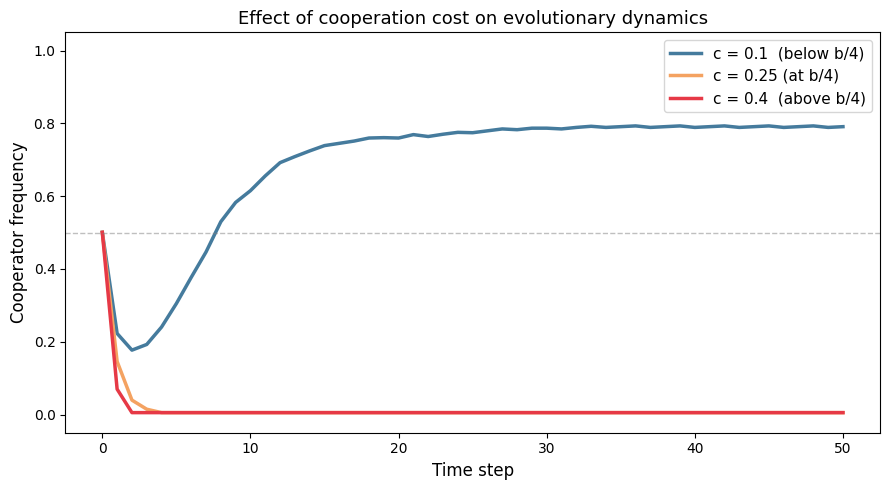

In [12]:
# ── EXPERIMENT: COMPARE DYNAMICS FOR DIFFERENT COST VALUES ───────────────

# Three representative cost values relative to the threshold b/4 = 0.25
c_low    = 0.10   # well below threshold → cooperation should thrive
c_border = 0.25   # right at the threshold → unstable
c_high   = 0.40   # above threshold → defection should take over

fig, ax = plt.subplots(figsize=(9, 5))

for c_val, color, label in [
    (c_low,    '#457b9d', f'c = {c_low}  (below b/4)'),
    (c_border, '#f4a261', f'c = {c_border} (at b/4)'),
    (c_high,   '#e63946', f'c = {c_high}  (above b/4)'),
]:
    hist, _ = run_simulation(L, b, c_val, init_coop_freq,
                              n_steps=50, seed=42)
    ax.plot(hist, color=color, linewidth=2.5, label=label)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel("Time step", fontsize=12)
ax.set_ylabel("Cooperator frequency", fontsize=12)
ax.set_title("Effect of cooperation cost on evolutionary dynamics", fontsize=13)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## Step 13 — Reflection: What the Model Shows

After running the simulations, take a moment to connect the results back to the theory.

### Questions to think about:

1. **The spatial dynamics (Step 9):** At $t=1$ and $t=2$, did cooperator frequency go *down* before going up? Why does that happen spatially — which cooperators survive and which don't?

2. **The phase transition (Step 11):** How sharp is the cliff at $c = b/4$? Is the transition exactly at $0.25$, or does it shift slightly across runs? What causes the variability?

3. **The grid geometry:** The threshold $c = b/4$ comes directly from having 4 neighbors. What do you think would happen if agents had 8 neighbors (including diagonals) instead of 4? Would the threshold shift?

4. **The network rigidity caveat:** Everything in this model assumes agents *never move*. Given what the chapter says about probabilistic randomization (Section 6.4), what do you predict would happen if you added even a 5% chance of agents swapping positions each time step?

---

### Key Results to Record:

| Parameter | Value | Result |
|---|---|---|
| `b=1, c=0.10` | Below threshold | Cooperation dominates (~80%) |
| `b=1, c=0.25` | At threshold | Unstable / variable |
| `b=1, c=0.40` | Above threshold | Defection dominates (~0%) |

---

## What's Next

The next exercise adds **probabilistic randomization** (Section 6.4): before each game-play stage, agents have a small probability of swapping positions with a randomly chosen agent. This disrupts the spatial assortment and tests how fragile the cooperation result is.

After that: **reciprocity** — replacing ALLC with TFT and adding multiple rounds per interaction.
